In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../output_csv/teses1_prompt_cod.csv")
df.columns = [c.replace('qwen/', '') for c in df.columns]
df = df.fillna(0)

In [5]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

In [6]:
mapping_tokens = {
    'gemma-3-27b-it_n_tokens_in': 'gemma-3-27b-it',
    'llama-3.3-70B-Instruct_n_tokens_in': 'llama-3.3-70B-Instruct',
    'mistral-small-3.2-24B-Instruct-2506_n_tokens_in': 'mistral-small-3.2-24B',
    'Phi-4-mini-instruct_n_tokens_in': 'Phi-4-mini-instruct',
    'qwen3-30b-a3b-2507_n_tokens_in': 'qwen3-30b-a3b-2507',
    'gpt-oss-120b_n_tokens_in': 'gpt-oss-120b'
}

mapping_latex = {
    'gemma-3-27b-it': 'Tokens (gemma-3-27b)',
    'llama-3.3-70B-Instruct': 'Tokens (llama-3.3-70B)',
    'mistral-small-3.2-24B': 'Tokens (mistral-small-3.2-24B-2506)',
    'Phi-4-mini-instruct': 'Tokens (Phi-4-mini-instruct)',
    'qwen3-30b-a3b-2507': 'Tokens (qwen3-30b-a3b-2507)',
    'gpt-oss-120b': 'Tokens (gpt-oss-120b)'
}

In [7]:
cols_analise = ['word_count'] + list(mapping_tokens.keys())
df_estatisticas = df[cols_analise].agg(['mean', 'min', 'max']).T

In [8]:
labels_linhas = {'word_count': 'Palavras'}
labels_linhas.update(mapping_tokens)
df_estatisticas.index = df_estatisticas.index.map(labels_linhas)

In [9]:
df_estatisticas_formatada = df_estatisticas.copy()
for col in df_estatisticas_formatada.columns:
    df_estatisticas_formatada[col] = df_estatisticas_formatada[col].map(lambda x: f"{int(x):,}".replace(',', '.'))

In [10]:
df_estatisticas_formatada = df_estatisticas_formatada.rename(index=mapping_latex)

df_estatisticas_formatada.columns = ['\\textbf{Média}', '\\textbf{Mínimo}', '\\textbf{Máximo}']

df_estatisticas_formatada = df_estatisticas_formatada.reset_index()

df_estatisticas_formatada.rename(columns={'index': '\\textbf{Métrica / Tokenizador}'}, inplace=True)

In [11]:
tabela_latex = df_estatisticas_formatada.to_latex(
    index=False, 
    column_format='lrrr', 
    escape=False, 
    position='htbp'
)

insercoes_latex = (
    "\\begin{table}[htbp]\n"
    "\\centering\n"
    "\\caption{Estatísticas descritivas de volume de palavras e de \\textit{tokens} do corpus selecionado.}\n"
    "\\label{tab:estatistica_corpus}"
)

tabela_latex = tabela_latex.replace("\\begin{table}[htbp]", insercoes_latex)

with open('../misc/tabela_estatistica_corpus.tex', 'w', encoding='utf-8') as f:
    f.write(tabela_latex)

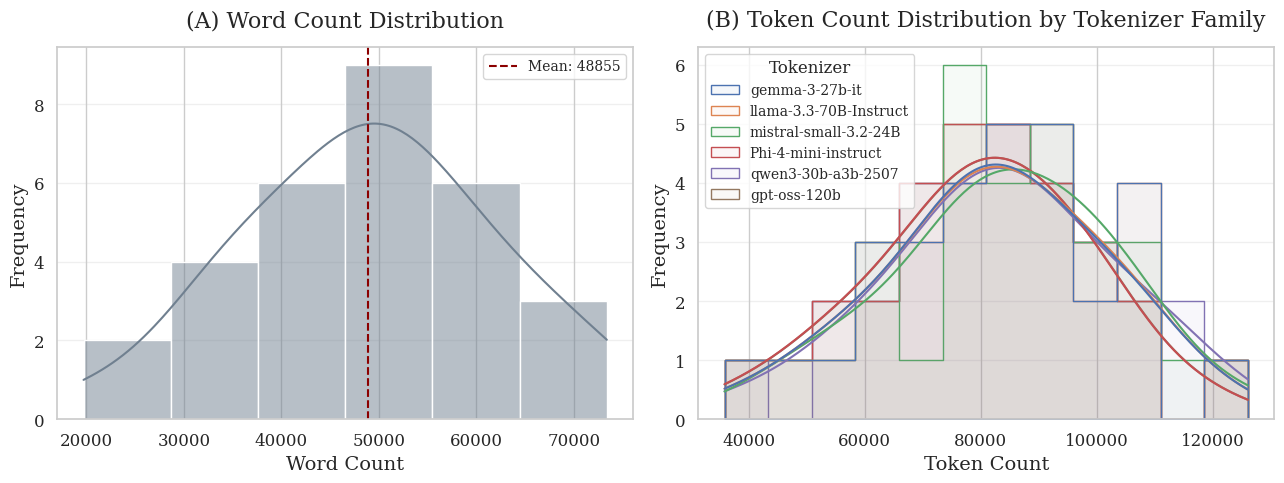

Processing completed successfully and files saved!


In [12]:
# Settings
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 10,
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Subplot A
sns.histplot(data=df, x='word_count', kde=True, color='slategray', ax=axes[0])
axes[0].axvline(df['word_count'].mean(), color='darkred', linestyle='--', label=f'Mean: {df["word_count"].mean():.0f}')
axes[0].set_title('(A) Word Count Distribution', pad=15)
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Subplot B
df_tokens_long = df[['title'] + list(mapping_tokens.keys())].rename(columns=mapping_tokens).melt(
    id_vars=['title'], var_name='Tokenizer', value_name='token_count'
)
sns.histplot(data=df_tokens_long, x='token_count', hue='Tokenizer', kde=True, element='step', stat='count', alpha=0.05, ax=axes[1])
axes[1].set_title('(B) Token Count Distribution by Tokenizer Family', pad=15)
axes[1].set_xlabel('Token Count')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../misc/corpus_word_token_distribution.pdf.pdf', bbox_inches='tight', dpi=300)
plt.show()
print("Processing completed successfully and files saved!")